# CV Baseline: Контурная детекция штампов

**Цель:** Проверить работоспособность contour-based эвристики для детекции штампов.

**Метод:**
1. Adaptive thresholding → бинаризация
2. findContours → поиск контуров
3. Union box: родительский контур + children
4. Проверка aspect ratio vs ожидаемый (~3.5:1)

**Данные:** 49 реальных изображений (без синтетики)

**Почему без синтетики:** CV baseline не улучшается от синтетических данных — эвристика работает на реальных контурах.


In [1]:
import sys
sys.path.insert(0, "..")

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

from src.data.loader import load_image_and_labels
from src.models.cv_baseline import CVBaselineDetector

DATA_DIR = Path("../data")
IMAGE_DIR = DATA_DIR / "images" / "test"
LABEL_DIR = DATA_DIR / "labels" / "test"

detector = CVBaselineDetector()

print("Настройка завершена")

Настройка завершена


## Функция IoU

Реализация Intersection over Union для оценки качества детекции.

In [2]:
from src.evaluation.metrics import bbox_iou, yolo_to_pixel

## Оценка на 35 изображениях (одинаковый сабсет с YOLO v3)

Запускаем CV baseline на том же подмножестве из 35 реальных non-donor, non-val изображений,
что использовалось для оценки YOLOv8n (v3). Исключены 4 донора и 10 val_honest.


In [3]:
from src.evaluation.evaluate_cv import evaluate_cv
from src.evaluation.metrics import compute_metrics
from src.config import load_donors, load_val_honest, load_config

cfg = load_config()
EXCLUDE = load_donors(cfg) | load_val_honest(cfg)

_metrics, results = evaluate_cv(detector, IMAGE_DIR, LABEL_DIR, EXCLUDE)
print(f"Обработано: {len(results)} изображений")
print(f"Найдено: {sum(1 for r in results if r.found)} ({sum(1 for r in results if r.found) / len(results) * 100:.1f}%)")
print(f"IoU mean: {np.mean([r.iou for r in results]):.3f}")
print(f"IoU median: {np.median([r.iou for r in results]):.3f}")
print(f"IoU > 0.5: {sum(1 for r in results if r.iou > 0.5)} ({sum(1 for r in results if r.iou > 0.5) / len(results) * 100:.1f}%)")


Обработано: 35 изображений
Найдено: 31 (88.6%)
IoU mean: 0.640
IoU median: 0.947
IoU > 0.5: 24 (68.6%)


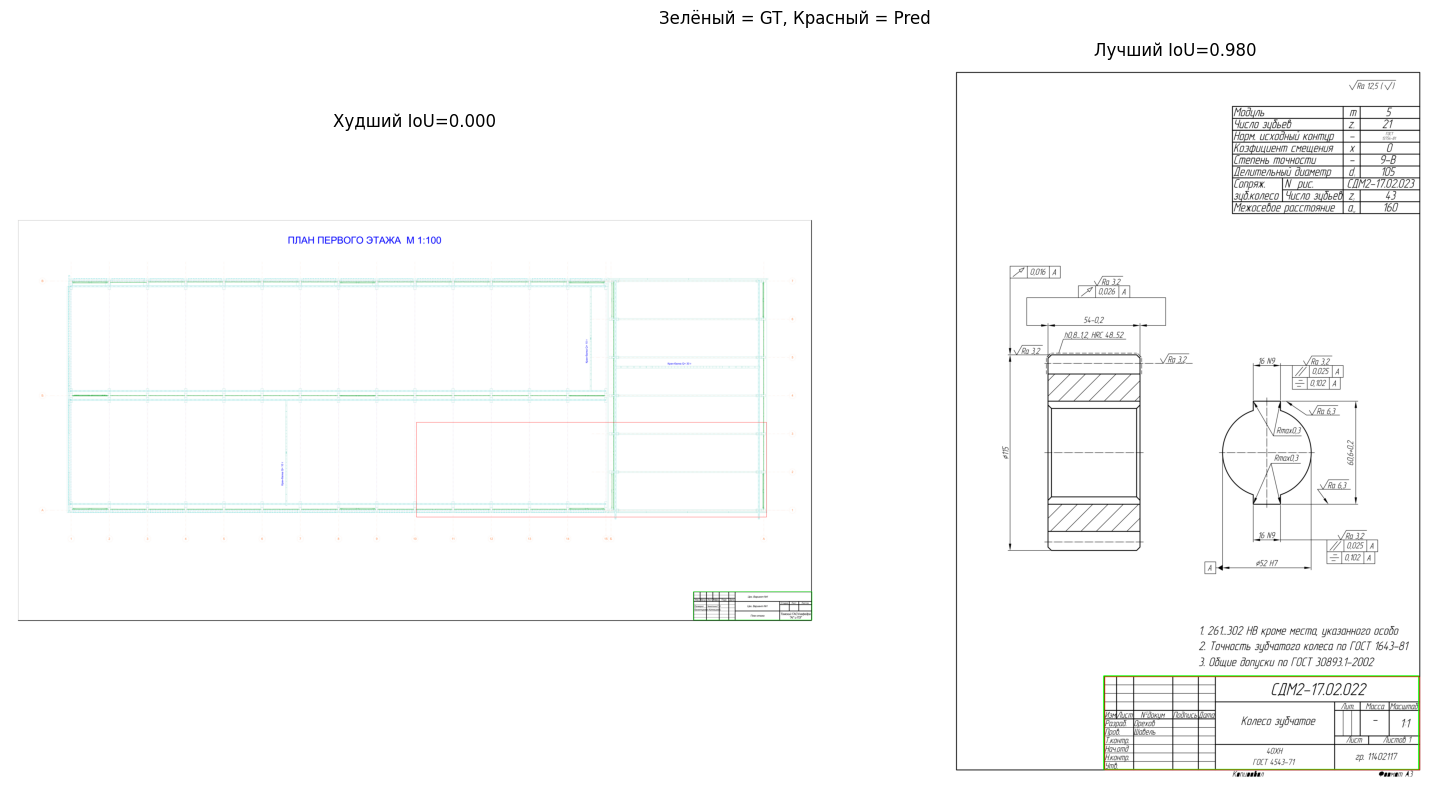

In [4]:
all_images = sorted(IMAGE_DIR.glob("*.png")) + sorted(IMAGE_DIR.glob("*.jpg"))
# Сортируем по IoU
sorted_results = sorted(results, key=lambda r: r.iou)

worst = sorted_results[0]
best = sorted_results[-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax_idx, (result, title_prefix) in enumerate([(worst, 'Худший'), (best, 'Лучший')]):
    img_path = [p for p in all_images if p.name == result.image_name][0]
    img, _ = load_image_and_labels(img_path, LABEL_DIR)
    
    vis = img.copy()
    
    if result.gt_bbox:
        x, y, w, h = result.gt_bbox
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 3)
    
    if result.pred_bbox:
        x, y, w, h = result.pred_bbox
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 0, 255), 2)
    
    axes[ax_idx].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[ax_idx].set_title(f'{title_prefix} IoU={result.iou:.3f}')
    axes[ax_idx].axis('off')

plt.suptitle('Зелёный = GT, Красный = Pred')
plt.tight_layout()
plt.show()

In [5]:
from src.evaluation.evaluate_cv import run_cv_evaluation
run_cv_evaluation()


CV  Images:         35
CV  Detected:        31 (88.6%)
CV  IoU mean:        0.640
CV  IoU std:         0.431
CV  IoU median:      0.947
CV  IoU >= 0.5:      68.6%
CV  Precision:       0.774
CV  Recall:          0.686
CV  F1:              0.727


{'n_images': 35,
 'n_found': 31,
 'detection_rate': 0.8857142857142857,
 'iou_mean': 0.6402908248837109,
 'iou_std': 0.4306309615639496,
 'iou_median': 0.9469647052973135,
 'iou_max': 0.9795029150046026,
 'iou_min': 0.0,
 'iou_found_mean': 0.7229089958364479,
 'iou_at_threshold': 0.6857142857142857,
 'precision': 0.7741935483870968,
 'recall': 0.6857142857142857,
 'f1': 0.7272727272727272,
 'tp': 24,
 'fp': 7,
 'fn': 11}